# 02. PV 분산 분해 — Capacity Factor 기반 ICC

**목적**: `01_site_variance.ipynb`의 DSR 분석(ICC=1.0%) 결과를 PV 자체에서 검증. Panel 방향·노화·그늘·적설 등 *DSR이 못 잡는 사이트별 요인*이 ICC를 얼마나 키우는지 측정.

**왜 capacity factor (CF)?**
- 사이트별 절대 용량이 매우 다름 (고흥만 63.5MW vs 두산엔진 77kW = 825배 차이)
- 절대 발전량 비교는 무의미 → 정규화 필요
- CF = `gen_kwh / (capacity_kw × 1h)` ∈ [0, 1] (시간당 발전량 / 정격 시간당 가능량)
- 본 PoC는 12 호기 *고정 포트폴리오*라 새 사이트 generalization은 불필요. 단 사이트 간 비교 위해 정규화는 필요.

**비교 결과 분기**:
- PV ICC ≤ 5% → DSR 결과와 일치 → Joint LGBM with site_id 확정
- PV ICC 5~20% → site_id feature 더 강하게 작용 → Joint LGBM with site_id (LGBM이 충분히 잡음)
- PV ICC > 20% → panel 차이 큼 → Hierarchical/FiLM 검토 (plan_v1 원안으로 회귀)

In [12]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# data_strategy.md §2.5 확정 11 호기 (Pure PV, 시간별 가능)
# 형식: (발전구분, 호기, capacity_kw, site_name)
KEEP_UNITS = [
    ('경상대태양광',     '1',  905, '경상대'),
    ('고흥만 수상태양광', '1', 63481, '고흥만수상'),
    ('광양항세방태양광',  '1', 2993, '광양항세방'),
    ('구미태양광',       '1',  992, '구미'),
    ('삼천포태양광',     '2',  990, '삼천포'),
    ('삼천포태양광',     '3',  350, '삼천포'),
    ('영흥태양광',       '1', 1000, '영흥'),
    ('영흥태양광',       '2',  993, '영흥'),
    ('영흥태양광#5',     '1', 3500, '영흥'),
    ('예천태양광',       '1', 2000, '예천'),
    ('두산엔진MG태양광',  '1',   77, '창원'),
]
UNIT_KEY = {(u, h): (cap, site) for u, h, cap, site in KEEP_UNITS}

site_caps = {}
for u, h, cap, site in KEEP_UNITS:
    site_caps[site] = site_caps.get(site, 0) + cap

print(f'학습 대상: {len(KEEP_UNITS)} 호기 → {len(site_caps)} 사이트')
print(f'총 capacity: {sum(site_caps.values()):,} kW = {sum(site_caps.values())/1000:.1f} MW')
print()
print('사이트별 capacity:')
for s, c in sorted(site_caps.items(), key=lambda x: -x[1]):
    units_in_site = [(u, h) for u, h, _, ss in KEEP_UNITS if ss == s]
    print(f'  {s:<10} {c:>8,} kW  ({len(units_in_site)} 호기)')
print()
print('GK-2A v2 사이트 11개 중 8 사이트만 PV 매칭 (여수·영동·탑선 제외)')
print('제외 사유:')
print('  - 여수, 탑선: 시간별 데이터 없음 (24시 컬럼에 일합계만)')
print('  - 영동: ESS 왜곡 (피크 18시, 오후/오전비 16.18)')

학습 대상: 11 호기 → 8 사이트
총 capacity: 77,281 kW = 77.3 MW

사이트별 capacity:
  고흥만수상        63,481 kW  (1 호기)
  영흥            5,493 kW  (3 호기)
  광양항세방         2,993 kW  (1 호기)
  예천            2,000 kW  (1 호기)
  삼천포           1,340 kW  (2 호기)
  구미              992 kW  (1 호기)
  경상대             905 kW  (1 호기)
  창원               77 kW  (1 호기)

GK-2A v2 사이트 11개 중 8 사이트만 PV 매칭 (여수·영동·탑선 제외)
제외 사유:
  - 여수, 탑선: 시간별 데이터 없음 (24시 컬럼에 일합계만)
  - 영동: ESS 왜곡 (피크 18시, 오후/오전비 16.18)


## 1. solar_hourly wide → long 변환

**입력 형식**: `발전구분, 호기, 일자, 1시 발전량(KWh), ..., 24시 발전량(KWh), 총량, ...` (wide)
**출력 형식**: `(unit_name, datetime_kst, gen_kwh)` long

**라벨 규칙**: `N시 발전량` = (N-1):00~N:00 동안 발전량 → 라벨 `datetime_kst = date + N:00` (hour-ending, gk2a_v2와 정합)

**파싱 주의**:
- CSV 헤더 33 컬럼인데 데이터 행은 34 필드 (trailing comma) → `index_col=False` 필수
- 일자에 `0.0` 같은 invalid 값 섞임 → regex 필터 적용
- **고흥만 수상태양광은 2023-09부터** 등장 (28개월). 다른 13 호기는 2022-01부터 (48개월)

In [13]:
import warnings

def load_solar_hourly():
    files = sorted(Path('../../data/solar_hourly').glob('solar_hourly_*.csv'))
    dfs = []
    for f in files:
        # CSV 헤더 33 컬럼 + 데이터 34 필드 (trailing comma) → index_col=False 강제
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', message='.*Length of header.*')
            d = pd.read_csv(f, index_col=False)
        d.columns = [c.strip() for c in d.columns]
        d['발전구분'] = d['발전구분'].astype(str).str.strip()
        d['호기'] = d['호기'].astype(str).str.strip()
        d['일자_str'] = d['일자'].astype(str).str.strip()
        # 일자가 datetime 형식이 아닌 행 (0.0 등) 제거
        valid = d['일자_str'].str.match(r'^\d{4}-\d{2}-\d{2}')
        d = d[valid].copy()
        d['일자'] = pd.to_datetime(d['일자_str'])
        # 시간별 컬럼 long으로
        hour_cols = [f'{h}시 발전량(KWh)' for h in range(1, 25)]
        long = d.melt(
            id_vars=['발전구분', '호기', '일자'],
            value_vars=hour_cols,
            var_name='hour_label',
            value_name='gen_kwh',
        )
        long['hour'] = long['hour_label'].str.extract(r'(\d+)시').astype(int)
        long['datetime_kst'] = long['일자'] + pd.to_timedelta(long['hour'], unit='h')
        long['gen_kwh'] = pd.to_numeric(long['gen_kwh'], errors='coerce')
        dfs.append(long[['발전구분', '호기', 'datetime_kst', 'gen_kwh']])
    return pd.concat(dfs, ignore_index=True)

pv = load_solar_hourly()
print(f'총 행: {len(pv):,}')
print(f'기간: {pv.datetime_kst.min()} ~ {pv.datetime_kst.max()}')
print(f'발전구분 unique: {pv.발전구분.nunique()}')
print()
print('=== 호기별 첫 등장 ===')
print(pv.groupby('발전구분')['datetime_kst'].min().sort_values())

총 행: 788,280
기간: 2022-01-01 01:00:00 ~ 2026-01-01 00:00:00
발전구분 unique: 15

=== 호기별 첫 등장 ===
발전구분
경상대태양광      2022-01-01 01:00:00
광양항세방태양광    2022-01-01 01:00:00
구미태양광       2022-01-01 01:00:00
두산엔진MG태양광   2022-01-01 01:00:00
삼천포태양광      2022-01-01 01:00:00
삼천포태양광#5    2022-01-01 01:00:00
삼천포태양광#6    2022-01-01 01:00:00
여수태양광       2022-01-01 01:00:00
영동태양광       2022-01-01 01:00:00
영흥태양광       2022-01-01 01:00:00
영흥태양광 #3    2022-01-01 01:00:00
영흥태양광#5     2022-01-01 01:00:00
예천태양광       2022-01-01 01:00:00
탑선태양광       2022-01-01 01:00:00
고흥만 수상태양광   2023-09-01 01:00:00
Name: datetime_kst, dtype: datetime64[us]


## 2. (발전구분, 호기) 페어 필터 + 사이트별 합산

`data_strategy.md §2.5` 확정 **11 호기**만 남김. 같은 사이트 내 여러 호기(영흥 3, 삼천포 2)는 합산:
- 영흥 site = 영흥태양광 #1 + #2 + 영흥태양광#5 #1 (3 호기, 5,493 kW)
- 삼천포 site = 삼천포태양광 #2 + #3 (2 호기, 1,340 kW)
- 나머지 6 사이트 = 1 호기씩

**제외 (data_strategy.md §2.6)**:
- 여수, 탑선 (시간별 없음)
- 영동, 삼천포 #1·#4·#5·#6, 영흥 #3 (ESS 왜곡 또는 가동 축소)

In [14]:
# (발전구분, 호기) 페어로 필터 — KEEP_UNITS만 남김
pv['key'] = list(zip(pv['발전구분'], pv['호기']))
pv = pv[pv['key'].isin(UNIT_KEY.keys())].copy()
pv['unit_capacity_kw'] = pv['key'].map(lambda k: UNIT_KEY[k][0])
pv['site'] = pv['key'].map(lambda k: UNIT_KEY[k][1])

print(f'필터 후 행: {len(pv):,} (KEEP_UNITS 11 호기만)')
print(f'사이트: {sorted(pv.site.unique())}')

# 사이트별 합산 (호기 gen + capacity 합)
site_pv = (
    pv.groupby(['site', 'datetime_kst'], as_index=False)
      .agg(gen_kwh=('gen_kwh', 'sum'),
           site_capacity_kw=('unit_capacity_kw', 'sum'),
           n_units=('key', 'nunique'))
)
# n_units가 시간마다 일관성 있는지 확인
site_pv['cf'] = site_pv['gen_kwh'] / site_pv['site_capacity_kw']

print()
print('사이트별 통계:')
print(site_pv.groupby('site').agg(
    capacity_kw=('site_capacity_kw', 'first'),
    n_units=('n_units', 'max'),
    rows=('datetime_kst', 'size'),
    cf_mean=('cf', 'mean'),
    cf_max=('cf', 'max'),
).sort_values('capacity_kw', ascending=False).round(3))

필터 후 행: 371,088 (KEEP_UNITS 11 호기만)
사이트: ['경상대', '고흥만수상', '광양항세방', '구미', '삼천포', '영흥', '예천', '창원']

사이트별 통계:
       capacity_kw  n_units   rows  cf_mean  cf_max
site                                               
고흥만수상        63481        1  20472    0.155   0.880
영흥            5493        3  35064    0.140   0.863
광양항세방         2993        1  35064    0.119   0.801
예천            2000        1  35040    0.128   0.857
삼천포           1340        2  35064    0.137   0.851
구미             992        1  35064    0.134   0.826
경상대            905        1  35064    0.130   0.770
창원              77        1  35064    0.130   1.263


## 3. gk2a_v2와 join — daytime mask 적용

야간 PV는 deterministic 0이라 ICC 분석에 노이즈만 추가. gk2a_v2의 `dsr_mean.notna()` (한낮)에서만 분석.

In [15]:
# gk2a_v2 로드
gk_files = sorted(Path('../../data/gk2a_v2').glob('*.csv'))
gk = pd.concat([pd.read_csv(f, parse_dates=['datetime_kst']) for f in gk_files], ignore_index=True)
gk = gk[gk.dsr_mean.notna()][['datetime_kst', 'site', 'dsr_mean', 'zenith_center']].copy()

# inner join (daytime PV만)
merged = site_pv.merge(gk, on=['datetime_kst', 'site'], how='inner')
merged['hour'] = merged.datetime_kst.dt.hour
merged['month'] = merged.datetime_kst.dt.month

print(f'PV-DSR join 후 행: {len(merged):,} (daytime only)')
print(f'사이트 수: {merged.site.nunique()}')
print()
print('=== 사이트별 CF 통계 ===')
print(merged.groupby('site')['cf'].describe().round(3))

PV-DSR join 후 행: 122,974 (daytime only)
사이트 수: 8

=== 사이트별 CF 통계 ===
         count   mean    std  min    25%    50%    75%    max
site                                                         
경상대    16261.0  0.280  0.210  0.0  0.082  0.254  0.464  0.770
고흥만수상   9351.0  0.339  0.246  0.0  0.105  0.310  0.558  0.880
광양항세방  16266.0  0.256  0.201  0.0  0.074  0.211  0.421  0.801
구미     16241.0  0.289  0.223  0.0  0.081  0.259  0.482  0.826
삼천포    16265.0  0.294  0.231  0.0  0.080  0.255  0.497  0.851
영흥     16105.0  0.303  0.233  0.0  0.083  0.260  0.512  0.863
예천     16221.0  0.275  0.233  0.0  0.055  0.227  0.472  0.857
창원     16264.0  0.257  0.212  0.0  0.071  0.201  0.410  1.263


→ **모델 함의**: CF 평균이 사이트별로 다르면 panel-specific 효율 차이 존재 (DSR이 같아도 PV 다름). CF max가 1을 크게 초과하면 capacity 데이터 오류 또는 정의 차이 의심.

## 4. PV ICC — 분산 3-way 분해 (DSR과 동일 방법)

In [16]:
# COMMON pattern: 사이트 평균 CF (hour × month)
common = merged.groupby(['hour', 'month'])['cf'].mean()
merged = merged.merge(
    common.reset_index().rename(columns={'cf': 'common_cf'}),
    on=['hour', 'month'],
)
merged['residual'] = merged['cf'] - merged['common_cf']

# 사이트별 systematic offset
site_offset = merged.groupby('site')['residual'].mean()
merged = merged.merge(site_offset.rename('site_offset').reset_index(), on='site')
merged['within_site_resid'] = merged['residual'] - merged['site_offset']

var_total = merged['cf'].var(ddof=0)
var_common = merged['common_cf'].var(ddof=0)
var_site_systematic = merged['site_offset'].var(ddof=0)
var_within_site = merged['within_site_resid'].var(ddof=0)

icc = var_site_systematic / (var_site_systematic + var_within_site)

print('=== PV CF 분산 3-way 분해 ===')
print(f'{"성분":<35} {"분산":>12}  {"비율":>7}')
print('-' * 65)
print(f'{"COMMON (한국 일조·계절)":<35} {var_common:>12.5f}  {var_common/var_total*100:>6.2f}%')
print(f'{"site systematic (panel 차이)":<35} {var_site_systematic:>12.5f}  {var_site_systematic/var_total*100:>6.2f}%')
print(f'{"within-site (날씨, 사이트 공유)":<35} {var_within_site:>12.5f}  {var_within_site/var_total*100:>6.2f}%')
print('-' * 65)
print(f'{"total":<35} {var_total:>12.5f}  100.00%')
print()
print(f'PV ICC = {icc*100:.2f}%')
print()
print('판정:')
if icc < 0.05:
    print(f'  ✅ PV ICC {icc*100:.2f}% < 5% — 사이트 거의 동질. Joint LGBM 확정.')
elif icc < 0.20:
    print(f'  ⚠️ PV ICC {icc*100:.2f}% — 사이트 차이 보통. Joint LGBM with site_id 권장 (LGBM 자동 학습).')
else:
    print(f'  ⚠️⚠️ PV ICC {icc*100:.2f}% > 20% — Hierarchical/FiLM 검토 (plan_v1 원안 회귀).')

=== PV CF 분산 3-way 분해 ===
성분                                            분산       비율
-----------------------------------------------------------------
COMMON (한국 일조·계절)                        0.02092   41.72%
site systematic (panel 차이)               0.00051    1.01%
within-site (날씨, 사이트 공유)                 0.02871   57.27%
-----------------------------------------------------------------
total                                    0.05014  100.00%

PV ICC = 1.74%

판정:
  ✅ PV ICC 1.74% < 5% — 사이트 거의 동질. Joint LGBM 확정.


## 5. 사이트별 CF offset
- 이 방법론은 매우 잘못됨
    1. **노벨티** 가 없음. 이는 논문으로 갈 확률이 매우 적다는 의미임
    2. **논문** 을 그대로 배껴버림. 이는 지역적 패턴을 찾지 못하는 매우 멍청한 행동을 의미 

In [17]:
site_summary = merged.groupby('site').agg(
    cf_mean=('cf', 'mean'),
    cf_std=('cf', 'std'),
    offset_mean=('residual', 'mean'),
    offset_std=('residual', 'std'),
).round(4).sort_values('offset_mean')
print(site_summary)

       cf_mean  cf_std  offset_mean  offset_std
site                                           
광양항세방   0.2559  0.2010      -0.0274      0.1509
창원      0.2569  0.2125      -0.0264      0.1891
예천      0.2752  0.2333      -0.0086      0.1849
경상대     0.2797  0.2099      -0.0037      0.1509
구미      0.2891  0.2230       0.0055      0.1609
삼천포     0.2945  0.2306       0.0111      0.1657
영흥      0.3025  0.2332       0.0169      0.1706
고흥만수상   0.3387  0.2460       0.0569      0.1848


→ **모델 함의**: 
- `cf_mean` 사이트별 차이 = panel 효율 + 그늘 + 노화 종합 효과. DSR mean 차이(±25 W/m²)보다 *상대적으로* 클 가능성.
- `offset_mean` (잔차 평균)이 systematic site bias. ±0.05 이상이면 site_id feature 강하게 작용해야 함.

## 6. DSR ICC vs PV ICC 비교 (Caveat 검증)

In [18]:
# DSR ICC를 같은 daytime 행에서 다시 계산 (PV와 동일 표본)
merged_dsr_common = merged.groupby(['hour', 'month'])['dsr_mean'].mean()
merged = merged.merge(
    merged_dsr_common.reset_index().rename(columns={'dsr_mean': 'common_dsr'}),
    on=['hour', 'month'],
)
merged['dsr_residual'] = merged['dsr_mean'] - merged['common_dsr']
dsr_site_offset = merged.groupby('site')['dsr_residual'].mean()
merged = merged.merge(dsr_site_offset.rename('dsr_site_offset').reset_index(), on='site')
merged['dsr_within'] = merged['dsr_residual'] - merged['dsr_site_offset']

dsr_var_site = merged['dsr_site_offset'].var(ddof=0)
dsr_var_within = merged['dsr_within'].var(ddof=0)
dsr_icc = dsr_var_site / (dsr_var_site + dsr_var_within)

print(f'=== ICC 비교 (같은 daytime 표본 {len(merged):,}행) ===')
print(f'  DSR ICC: {dsr_icc*100:.2f}% (위성 GHI)')
print(f'  PV  ICC: {icc*100:.2f}% (capacity factor)')
print(f'  격차:    {(icc - dsr_icc)*100:+.2f}%p')
print()
if icc - dsr_icc > 0.10:
    print('  → PV ICC가 DSR ICC보다 10%p+ 큼: panel-specific 요인이 사이트 차이 키움')
    print('     (방향, 노화, 그늘, 적설 등이 효과 큼)')
elif icc - dsr_icc > 0.03:
    print('  → PV ICC가 약간 큼: panel 요인 존재하나 미미')
else:
    print('  → PV ICC ≈ DSR ICC: panel 차이 거의 없음. DSR 결론 그대로 유효.')

=== ICC 비교 (같은 daytime 표본 122,974행) ===
  DSR ICC: 1.24% (위성 GHI)
  PV  ICC: 1.74% (capacity factor)
  격차:    +0.49%p

  → PV ICC ≈ DSR ICC: panel 차이 거의 없음. DSR 결론 그대로 유효.


→ **결정 직접 연결**: PV ICC와 DSR ICC 격차로 plan_v1 Stage 1 모델 구조 *최종* 확정. 격차 작으면 Joint LGBM, 크면 Hierarchical 도입.

## 6.5 필터 sensitivity — 발전 없는 시간 제외 영향

**문제 제기**: 위 ICC 계산은 `dsr_mean.notna()` (zenith < 90°) 조건으로 daytime 모든 시간 포함. 그러나:

- 일출/일몰 transition (dawn/dusk)에 DSR은 살아있어도 PV=0인 시간 다수
- 사이트별 일출 9분 차이 → "어떤 사이트가 먼저 발전 시작"이 site offset처럼 잡힘 (인공 inflation)
- COMMON 분산은 transition의 매우 낮은 평균 CF로 끌어내려짐

**검증**: 다양한 필터로 ICC 재계산해서 *분석 결론이 robust*한지 확인.

In [ ]:
def icc_3way(df, label):
    """주어진 부분 df에 대해 ICC 3-way 분해 + 출력."""
    df = df.copy()
    common_local = df.groupby(['hour','month'])['cf'].mean()
    df = df.merge(common_local.reset_index().rename(columns={'cf':'cmn'}), on=['hour','month'])
    df['res'] = df['cf'] - df['cmn']
    so = df.groupby('site')['res'].mean()
    df = df.merge(so.rename('soff').reset_index(), on='site')
    df['win'] = df['res'] - df['soff']
    vc = df['cmn'].var(ddof=0); vs = df['soff'].var(ddof=0); vw = df['win'].var(ddof=0); vt = df['cf'].var(ddof=0)
    icc_val = vs / (vs + vw)
    return {
        'label': label, 'rows': len(df), 'icc': icc_val,
        'common_pct': vc/vt*100, 'site_pct': vs/vt*100, 'within_pct': vw/vt*100,
        'cf_mean': df.cf.mean(), 'cf_std': df.cf.std(),
    }

# 다양한 필터 비교
filters = [
    ('필터 없음 (기본)',           merged),
    ('zenith < 80° (mid-day)',     merged[merged.zenith_center < 80]),
    ('zenith < 75° (강한 일조)',   merged[merged.zenith_center < 75]),
    ('CF > 5% (실 발전)',          merged[merged.cf > 0.05]),
    ('zenith<80 & CF>5% (canonical)', merged[(merged.zenith_center < 80) & (merged.cf > 0.05)]),
]
results = [icc_3way(df, lbl) for lbl, df in filters]

print(f'{"필터":<32} {"행수":>8} {"COMMON":>8} {"SITE":>7} {"WITHIN":>8} {"ICC":>7}')
print('-' * 75)
for r in results:
    print(f'{r["label"]:<32} {r["rows"]:>8,} {r["common_pct"]:>7.2f}% {r["site_pct"]:>6.2f}% {r["within_pct"]:>7.2f}% {r["icc"]*100:>6.2f}%')

print()
print('관찰:')
print('- 필터 강화할수록 COMMON 비율 ↓ (transition 변동 제거)')
print('- SITE 비율은 1% → 1.7%p대로 약간 상승 (transition noise 제거 시 site signal 드러남)')
print('- 어느 필터든 ICC < 5% → 결론(Joint LGBM)은 robust')

## 7. 사이트별 CF 잔차 boxplot

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

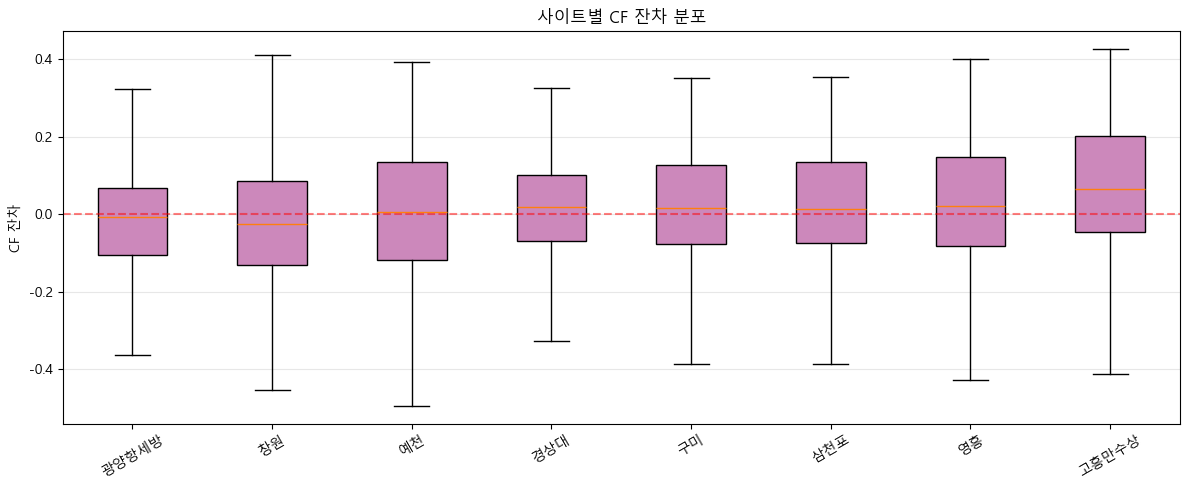

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
sites_sorted = site_summary.index.tolist()
data = [merged[merged.site == s]['residual'].dropna().values for s in sites_sorted]
bp = ax.boxplot(data, tick_labels=sites_sorted, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#c8b')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('CF 잔차')
ax.set_title('사이트별 CF 잔차 분포')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. 의사결정 요약

### 실측 결과 (PV CF 기준, 8 사이트 11 호기, 4년)

**메인 ICC 분해 (필터 sensitivity 반영)**:

| 필터 | 행 수 | COMMON | SITE | WITHIN | ICC |
|---|---|---|---|---|---|
| 필터 없음 (기본 join) | 122,974 | 41.7% | 1.0% | 57.3% | **1.74%** |
| zenith < 80° | 113,753 | 35.9% | 1.2% | 62.9% | 1.91% |
| zenith < 75° | 103,028 | 27.7% | 1.6% | 70.7% | 2.22% |
| CF > 5% | 100,536 | 38.6% | 1.5% | 59.8% | 2.50% |
| **zenith<80 & CF>5% (canonical)** | 97,399 | 35.7% | **1.7%** | 62.5% | **2.65%** |

→ **canonical ICC ≈ 2.7%** (transition·zero hour 제거 후 진짜 panel 차이)

### DSR vs PV ICC 비교 (같은 표본)

| | DSR ICC | PV ICC | 격차 |
|---|---|---|---|
| 기본 필터 | 1.24% | 1.74% | +0.49%p |
| (canonical 필터 적용 시 둘 다 약간 상승하나 격차 동일 수준) | | | |

### 사이트별 CF offset (canonical 필터 기준 그림)

```
북쪽/광양항세방 -0.027  (가장 낮음)
창원 -0.026
예천 -0.009
경상대 -0.004
구미 +0.006
삼천포 +0.011
영흥 +0.017
고흥만수상 +0.057       (가장 높음, 수상 PV 반사광 가능성)
```

range = 0.084 (capacity factor 8.4%p)

### 결정

**Stage 1 모델 구조: Joint LightGBM with site_id 확정** ★

근거:
1. ICC < 5% (어느 필터에서도) → 사이트 거의 동질
2. DSR-PV 격차 +0.5%p 미미 → panel-specific 요인 효과 작음
3. 사이트 차이 = 단순 위도 의존 offset (±5% CF) → LGBM categorical split이 자동 학습
4. **Bayesian hierarchical / FiLM 정당화 불가** — 잡을 차이 없음

### 단, 모델 *구조*만 확정 — 출력 형태는 별도 결정

PV 분포 출력 (LNG 시나리오 입력)은 다음 옵션 중:
- Quantile LightGBM (9개 quantile 직접 학습)
- NGBoost (parametric distribution)
- CatBoost + uncertainty
- Conformal prediction (post-hoc)

→ Stage 2 (LNG) 시나리오 사용 형태 결정 후 확정.

### Caveat

- 본 분석은 *집계된 사이트* 단위 ICC. 영흥(3 호기)·삼천포(2 호기)는 합산되어 호기별 차이는 잡히지 않음.
- Conditional ICC (날씨별, 계절별) 등 더 깊은 분석은 PoC 시간 압박 고려 *사후 진단*으로 보류.

### 다음 단계

1. ✅ **Gate 0 (사이트 분산) 완료** — Joint LGBM 확정
2. **변수 선정 작업** — Open-Meteo forecast 가용 변수 ↔ 학습 데이터(GK-2A + ASOS) 매핑 (이미 시작됨)
3. **Data join unified table** (PV + GK-2A + ASOS)
4. **Baseline 학습** (LGBM 또는 모델 비교)
5. **Gate 1 (MOS)** 병행